<a href="https://colab.research.google.com/github/udlbook/udlbook/blob/main/Notebooks/Chap04/4_1_Composing_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 4.1 -- Composing networks

The purpose of this notebook is to understand what happens when we feed one neural network into another. It works through an example similar to 4.1 and varies both networks

Work through the cells below, running each cell in turn. In various places you will see the words "TODO". Follow the instructions at these places and make predictions about what is going to happen or write code to complete the functions.

Contact me at udlbookmail@gmail.com if you find any mistakes or have any suggestions

In [1]:
import matplotlib as mpl
mpl.rcParams['font.sans-serif']=['Microsoft YaHei','SimHei','DejaVu Sans']
mpl.rcParams['axes.unicode_minus']=False
# Imports math library
import numpy as np
# Imports plotting library
import matplotlib.pyplot as plt

In [2]:
# Define the Rectified Linear Unit (ReLU) function
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation

In [3]:
# Define a shallow neural network with, one input, one output, and three hidden units
def shallow_1_1_3(x, activation_fn, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31):
  # Initial lines
  pre_1 = theta_10 + theta_11 * x
  pre_2 = theta_20 + theta_21 * x
  pre_3 = theta_30 + theta_31 * x
  # Activation functions
  act_1 = activation_fn(pre_1)
  act_2 = activation_fn(pre_2)
  act_3 = activation_fn(pre_3)
  # Weight activations
  w_act_1 = phi_1 * act_1
  w_act_2 = phi_2 * act_2
  w_act_3 = phi_3 * act_3
  # Combine weighted activation and add y offset
  y = phi_0 + w_act_1 + w_act_2 + w_act_3
  # Return everything we have calculated
  return y

In [4]:
# # Plot two shallow neural networks and the composition of the two
def plot_neural_two_components(x_in, net1_out, net2_out, net12_out=None):

  # Plot the two networks separately
  fig, ax = plt.subplots(1,2)
  fig.set_size_inches(8.5, 8.5)
  fig.tight_layout(pad=3.0)
  ax[0].plot(x_in, net1_out,'r-')
  ax[0].set_xlabel('Net 1 input'); ax[0].set_ylabel('Net 1 output')
  ax[0].set_xlim([-1,1]);ax[0].set_ylim([-1,1])
  ax[0].set_aspect(1.0)
  ax[1].plot(x_in, net2_out,'b-')
  ax[1].set_xlabel('Net 2 input'); ax[1].set_ylabel('Net 2 output')
  ax[1].set_xlim([-1,1]);ax[1].set_ylim([-1,1])
  ax[1].set_aspect(1.0)
  plt.show()

  if net12_out is not None:
    # Plot their composition
    fig, ax = plt.subplots()
    ax.plot(x_in ,net12_out,'g-')
    ax.set_xlabel('Net 1 Input'); ax.set_ylabel('Net 2 Output')
    ax.set_xlim([-1,1]);ax.set_ylim([-1,1])
    ax.set_aspect(1.0)
    plt.show()

Let's define two networks.  We'll put the prefixes n1_ and n2_ before all the variables to make it clear which network is which.  We'll just consider the inputs and outputs over the range [-1,1].

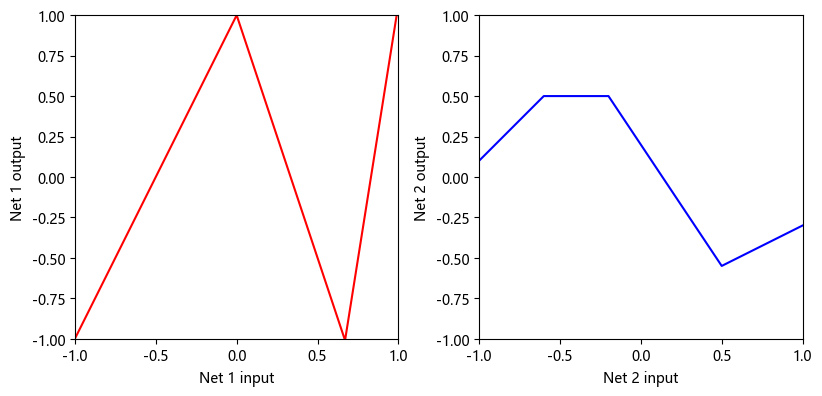

In [5]:
# Now lets define some parameters and run the first neural network
n1_theta_10 = 0.0   ; n1_theta_11 = -1.0
n1_theta_20 = 0     ; n1_theta_21 = 1.0
n1_theta_30 = -0.67 ; n1_theta_31 =  1.0
n1_phi_0 = 1.0; n1_phi_1 = -2.0; n1_phi_2 = -3.0; n1_phi_3 = 9.3

# Now lets define some parameters and run the second neural network
n2_theta_10 =  -0.6 ; n2_theta_11 = -1.0
n2_theta_20 =  0.2  ; n2_theta_21 = 1.0
n2_theta_30 =  -0.5  ; n2_theta_31 =  1.0
n2_phi_0 = 0.5; n2_phi_1 = -1.0; n2_phi_2 = -1.5; n2_phi_3 = 2.0

# Display the two inputs
x = np.arange(-1,1,0.001)
# We run the first  and second neural networks for each of these input values
net1_out = shallow_1_1_3(x, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
net2_out = shallow_1_1_3(x, ReLU, n2_phi_0, n2_phi_1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
# Plot both graphs
plot_neural_two_components(x, net1_out, net2_out)

In [6]:
# TODO
# Take a piece of paper and draw what you think will happen when we feed the
# output of the first network into the second one.  Draw the relationship between
# the input of the first network and the output of the second one.
# 解析结构性预测：f 的三段折叠会让 g 的阈值在不同输入分支产生多个原像，故 g(f(x)) 会比任一浅层网络有更多折点。执行单元随后给出数值核对；不伪造手绘经历。

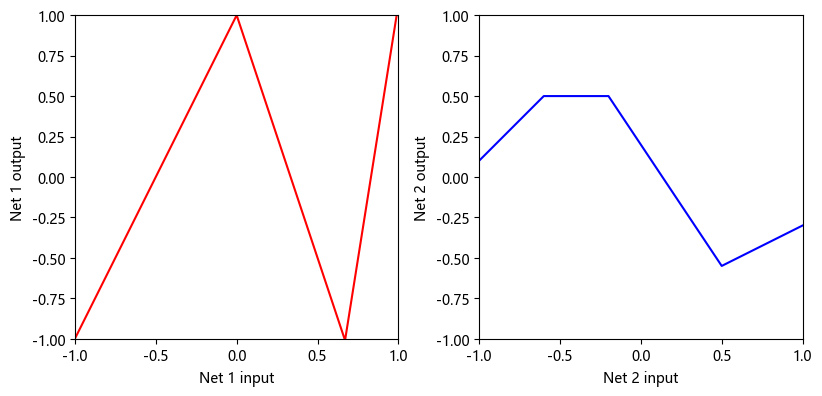

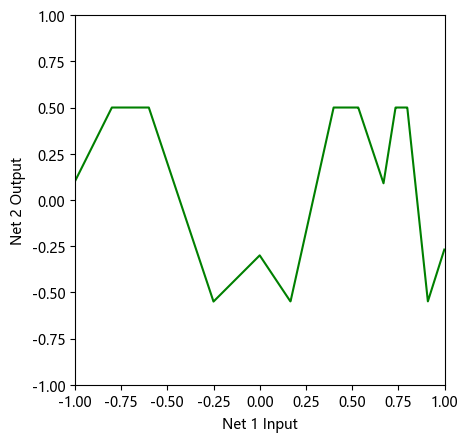

In [7]:
# Now let's see if your predictions were right

# TODO feed the output of first network into second network (replace this line)
net12_out = shallow_1_1_3(net1_out, ReLU, n2_phi_0, n2_phi_1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)

# Plot all three graphs
plot_neural_two_components(x, net1_out, net2_out, net12_out)

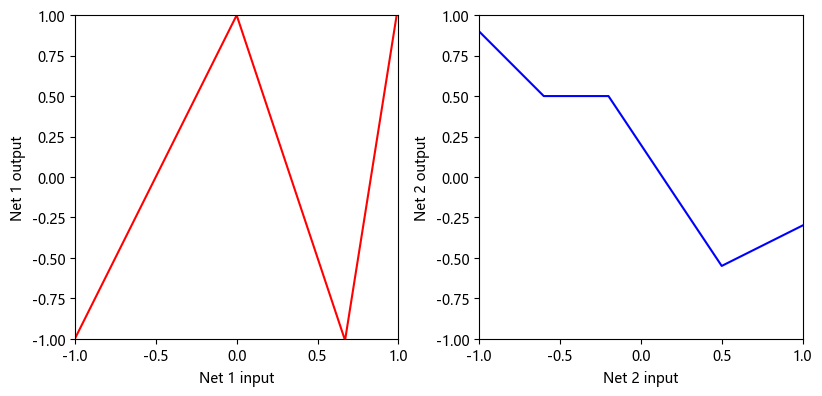

In [8]:
# Now we'll change things a up a bit.  What happens if we change the second network? (note the *-1 change)
net1_out = shallow_1_1_3(x, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
net2_out = shallow_1_1_3(x, ReLU, n2_phi_0, n2_phi_1*-1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
plot_neural_two_components(x, net1_out, net2_out)

In [9]:
# TODO
# Take a piece of paper and draw what you think will happen when we feed the
# output of the first network into the modified second network.  Draw the relationship between
# the input of the first network and the output of the second one.
# 解析结构性预测：只把外层 n2_phi_1 变号不会移动候选阈值原像，但会改变激活区间内的输出斜率；最终区域数预计仍为 12。执行单元随后核对。

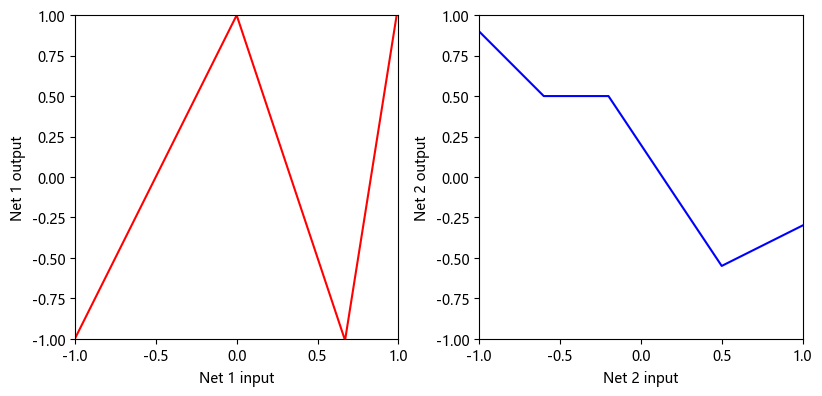

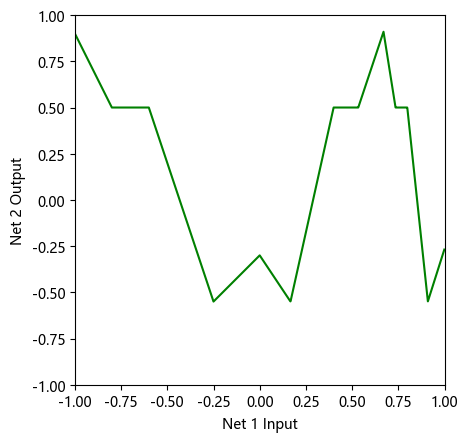

In [10]:
# When you have a prediction, run this code to see if you were right
net12_out = shallow_1_1_3(net1_out, ReLU, n2_phi_0, n2_phi_1*-1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
plot_neural_two_components(x, net1_out, net2_out, net12_out)

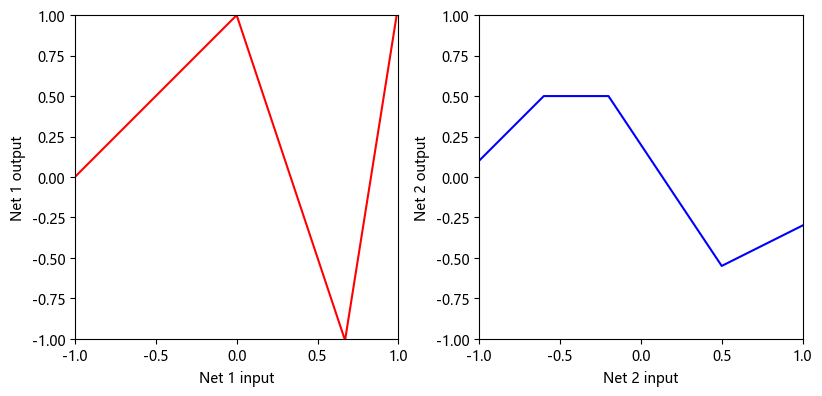

In [11]:
# Let's change things again.  What happens if we change the first network? (note the changes)
net1_out = shallow_1_1_3(x, ReLU, n1_phi_0, n1_phi_1*0.5, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
net2_out = shallow_1_1_3(x, ReLU, n2_phi_0, n2_phi_1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
plot_neural_two_components(x, net1_out, net2_out)

In [12]:
# TODO
# Take a piece of paper and draw what you think will happen when we feed the
# output of the modified first network into the original second network.  Draw the relationship between
# the input of the first network and the output of the second one.
# 解析结构性预测：只把内层 n1_phi_1 缩半会改变第一分支值域，部分外层阈值不再被覆盖，区域数预计由 12 降为 10。执行单元随后核对。

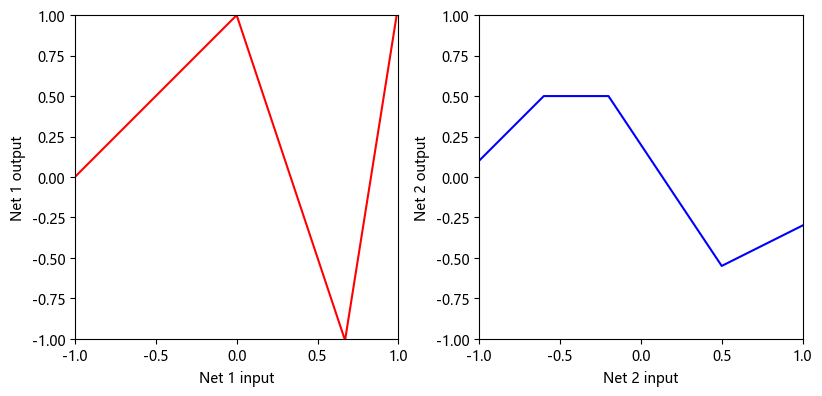

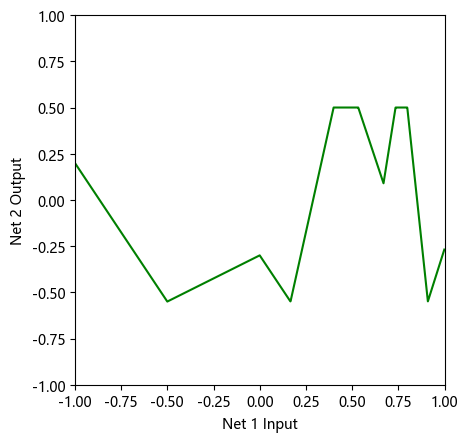

In [13]:
# When you have a prediction, run this code to see if you were right
net12_out = shallow_1_1_3(net1_out, ReLU, n2_phi_0, n2_phi_1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
plot_neural_two_components(x, net1_out, net2_out, net12_out)

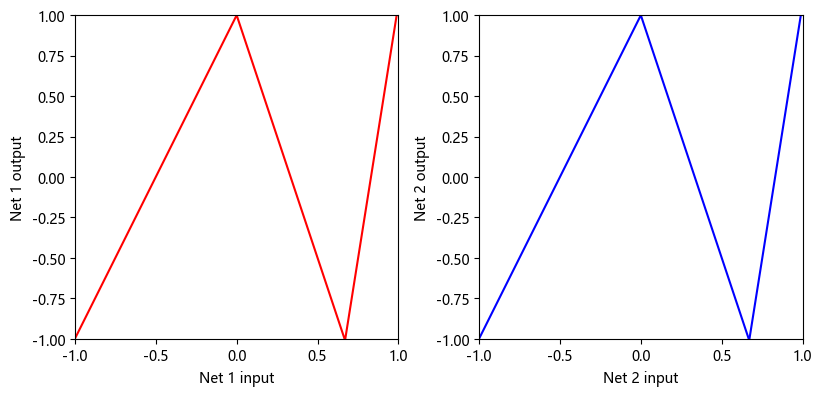

In [14]:
# Let's change things again.  What happens if the first network and second networks are the same?
net1_out = shallow_1_1_3(x, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
net2_out_new = shallow_1_1_3(x, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
plot_neural_two_components(x, net1_out, net2_out_new)

In [15]:
# TODO
# Take a piece of paper and draw what you think will happen when we feed the
# output of the first network into the a copy of itself.  Draw the relationship between
# the input of the first network and the output of the second one.
# 解析结构性预测：f 的三个非退化分支再次经过 f 后，各自复制其折线片段，当前构造预计得到 9 个最终线性区域。执行单元随后核对。

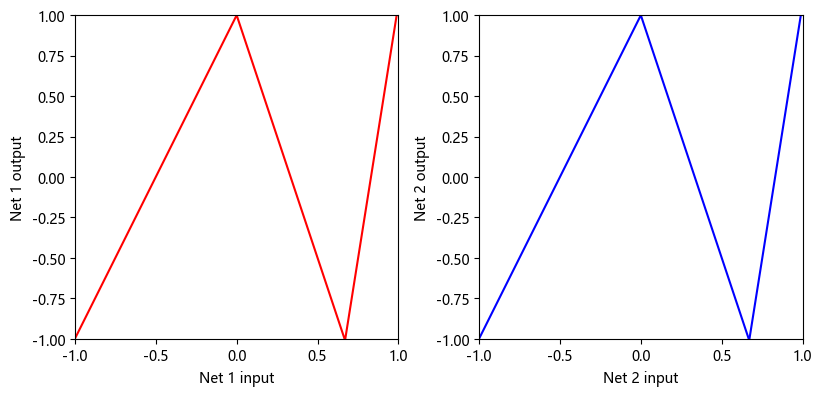

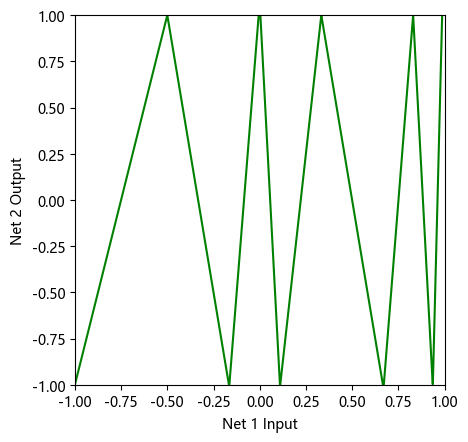

In [16]:
# When you have a prediction, run this code to see if you were right
net12_out = shallow_1_1_3(net1_out, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
plot_neural_two_components(x, net1_out, net2_out_new, net12_out)

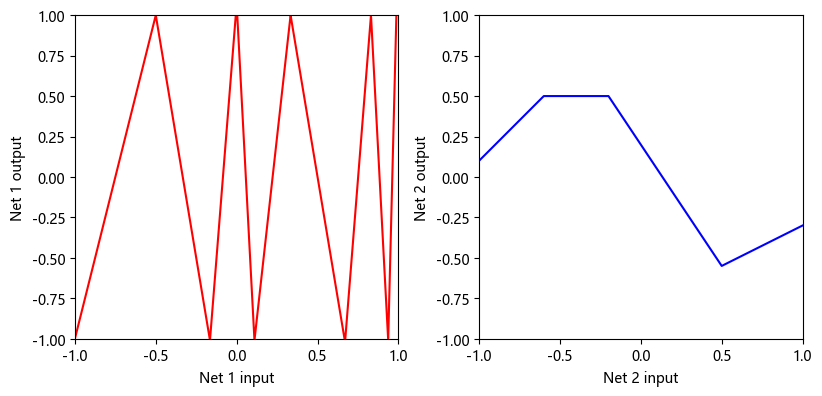

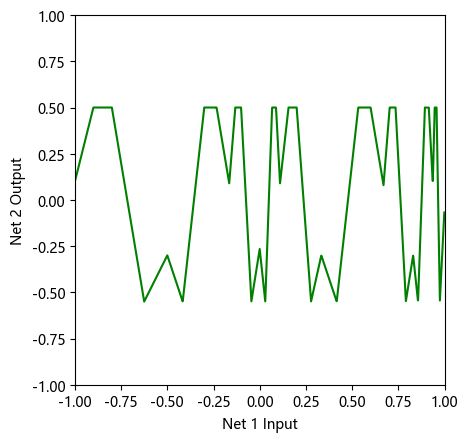

In [17]:
# TODO
# Contemplate what you think will happen when we feed the
# output of the original first network into a second copy of the original first network, and then
# the output of that into the original second network (so now we have a three layer network)
# How many total linear regions will we have in the output?
net123_out = shallow_1_1_3(net12_out, ReLU, n2_phi_0, n2_phi_1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
plot_neural_two_components(x, net12_out, net2_out, net123_out)
# 解析预测：当前具体参数下 g(f(f(x))) 有 36 个最大连续线性区域。

In [18]:
# TODO
# How many linear regions would there be if we ran N copies of the first network, feeding the result of the first
# into the second, the second into the third and so on, and then passed the result into the original second
# network (blue curve above)

# Take away conclusion:  with very few parameters, we can make A LOT of linear regions, but
# they depend on one another in complex ways that quickly become too difficult to understand intuitively.
# 解析预测：当前构造为 4×3^N；它依赖每个分支覆盖后续阈值且不存在退化/抵消，不是任意 ReLU 网络定律。

In [19]:
# 精确一维分段仿射传播（Fraction），所有计数均由本单元实际计算。
from fractions import Fraction
import numpy as np
import matplotlib.pyplot as plt

def Q(v): return Fraction(str(v))
F = {"phi": (1., -2., -3., 9.3), "theta": ((0.,-1.), (0.,1.), (-.67,1.))}
G = {"phi": (.5, -1., -1.5, 2.), "theta": ((-.6,-1.), (.2,1.), (-.5,1.))}

def merge_pieces(pieces):
    merged = []
    for p in pieces:
        if merged and (merged[-1]["slope"], merged[-1]["intercept"]) == (p["slope"], p["intercept"]):
            merged[-1]["right"] = p["right"]
            merged[-1]["sources"] += p["sources"]
        else:
            merged.append(dict(p))
    return merged

def shallow_pieces(params, lo=-1, hi=1):
    lo, hi = Q(lo), Q(hi); cuts = {lo, hi}; sources = {}
    for j, (b,w) in enumerate(params["theta"], 1):
        b,w = Q(b),Q(w)
        if w:
            root = -b/w
            if lo < root < hi: cuts.add(root); sources.setdefault(root,[]).append(f"内层神经元{j}")
    result=[]; edges=sorted(cuts)
    for left,right in zip(edges[:-1],edges[1:]):
        mid=(left+right)/2; slope=Fraction(0); intercept=Q(params["phi"][0]); active=[]
        for coef,(b,w) in zip(params["phi"][1:],params["theta"]):
            coef,b,w=Q(coef),Q(b),Q(w); on=b+w*mid>0; active.append(bool(on))
            if on: slope += coef*w; intercept += coef*b
        result.append({"left":left,"right":right,"slope":slope,"intercept":intercept,
                       "active":tuple(active),"sources":sources.get(left,[])})
    return merge_pieces(result)

def compose_pieces(inner, outer):
    result=[]
    for base in inner:
        a,c=base["slope"],base["intercept"]; cuts={base["left"],base["right"]}; src={}
        for j,(b,w) in enumerate(outer["theta"],1):
            b,w=Q(b),Q(w)
            if w*a:
                root=-(b+w*c)/(w*a)
                if base["left"] < root < base["right"]:
                    cuts.add(root); src.setdefault(root,[]).append(f"外层神经元{j}阈值原像")
        edges=sorted(cuts)
        for left,right in zip(edges[:-1],edges[1:]):
            mid=(left+right)/2; slope=Fraction(0); intercept=Q(outer["phi"][0]); active=[]
            for coef,(b,w) in zip(outer["phi"][1:],outer["theta"]):
                coef,b,w=Q(coef),Q(b),Q(w); on=b+w*(a*mid+c)>0; active.append(bool(on))
                if on: slope += coef*w*a; intercept += coef*(b+w*c)
            result.append({"left":left,"right":right,"slope":slope,"intercept":intercept,
                           "active":tuple(active),"sources":src.get(left,[])})
    return merge_pieces(result)

def iterate(n, first=F, second=G):
    pieces=shallow_pieces(first)
    for _ in range(1,n): pieces=compose_pieces(pieces,first)
    return pieces,compose_pieces(pieces,second)

f_piece=shallow_pieces(F); g_piece=shallow_pieces(G)
base=iterate(1)[1]
flip_g=dict(G); flip_g["phi"]=(.5,1.,-1.5,2.)
half_f=dict(F); half_f["phi"]=(1.,-1.,-3.,9.3)
ff=iterate(2)[0]; gff=iterate(2)[1]
counts_f=[len(iterate(n)[0]) for n in range(1,6)]
counts_g=[len(iterate(n)[1]) for n in range(1,6)]
measured={"f":len(f_piece),"g":len(g_piece),"base":len(base),
          "flip_g":len(compose_pieces(f_piece,flip_g)),
          "half_f":len(compose_pieces(shallow_pieces(half_f),G)),
          "f(f)":len(ff),"g(f(f))":len(gff)}
assert measured == {"f":3,"g":4,"base":12,"flip_g":12,"half_f":10,"f(f)":9,"g(f(f))":36}
assert counts_f == [3,9,27,81,243] and counts_g == [12,36,108,324,972]
print("本地精确传播区域数：", measured)
print("N=1..5：f^N",counts_f,"；g(f^N)",counts_g)
print("base 复合分段表（端点、斜率、截距、激活状态、来源）：")
for k,p in enumerate(base,1):
    print(k, str(p["left"]), str(p["right"]), str(p["slope"]), str(p["intercept"]), p["active"], p["sources"])

本地精确传播区域数： {'f': 3, 'g': 4, 'base': 12, 'flip_g': 12, 'half_f': 10, 'f(f)': 9, 'g(f(f))': 36}
N=1..5：f^N [3, 9, 27, 81, 243] ；g(f^N) [12, 36, 108, 324, 972]
base 复合分段表（端点、斜率、截距、激活状态、来源）：
1 -1 -4/5 2 21/10 (True, False, False) []
2 -4/5 -3/5 0 1/2 (False, False, False) ['外层神经元1阈值原像']
3 -3/5 -1/4 -3 -13/10 (False, True, False) ['外层神经元2阈值原像']
4 -1/4 0 1 -3/10 (False, True, True) ['外层神经元3阈值原像']
5 0 1/6 -3/2 -3/10 (False, True, True) []
6 1/6 2/5 9/2 -13/10 (False, True, False) ['外层神经元3阈值原像']
7 2/5 8/15 0 1/2 (False, False, False) ['外层神经元2阈值原像']
8 8/15 67/100 -3 21/10 (True, False, False) ['外层神经元1阈值原像']
9 67/100 4631/6300 63/10 -4131/1000 (True, False, False) []
10 4631/6300 559/700 0 1/2 (False, False, False) ['外层神经元1阈值原像']
11 559/700 5731/6300 -189/20 16093/2000 (False, True, False) ['外层神经元2阈值原像']
12 5731/6300 1 63/20 -6831/2000 (False, True, True) ['外层神经元3阈值原像']


In [20]:
# 普通 NumPy 前向与精确分段的内部点、折点两侧和端点核对。
def f_np(t): return shallow_1_1_3(np.asarray(t),ReLU,n1_phi_0,n1_phi_1,n1_phi_2,n1_phi_3,n1_theta_10,n1_theta_11,n1_theta_20,n1_theta_21,n1_theta_30,n1_theta_31)
def g_np(t): return shallow_1_1_3(np.asarray(t),ReLU,n2_phi_0,n2_phi_1,n2_phi_2,n2_phi_3,n2_theta_10,n2_theta_11,n2_theta_20,n2_theta_21,n2_theta_30,n2_theta_31)
probes={-1.,1.}
for p in base:
    l,r=float(p["left"]),float(p["right"]); probes.add((l+r)/2)
    for e in (l,r): probes.update((max(-1,e-1e-9),min(1,e+1e-9)))
probes=np.array(sorted(probes)); expected=[]
for xq in probes:
    p=next((p for p in base if float(p["left"])-1e-14 <= xq <= float(p["right"])+1e-14),base[-1])
    expected.append(float(p["slope"]*Q(xq)+p["intercept"]))
np.testing.assert_allclose(g_np(f_np(probes)),expected,atol=2e-8,rtol=2e-8)
print("分段表与 NumPy 前向最大绝对误差：",np.max(np.abs(g_np(f_np(probes))-expected)))
print("f(0.67), f(1)=",f_np([.67,1.]))
xs=np.array([-.9,-.5,-.1,.3,.7,.95]); print("x→f(x)→g(f(x))")
for a,b,c in zip(xs,f_np(xs),g_np(f_np(xs))): print(f"{a: .3f} → {b: .6f} → {c: .6f}")

分段表与 NumPy 前向最大绝对误差： 1.1102230246251565e-15
f(0.67), f(1)= [-1.01   1.069]
x→f(x)→g(f(x))
-0.900 → -0.800000 →  0.300000
-0.500 →  0.000000 →  0.200000
-0.100 →  0.800000 → -0.400000
 0.300 →  0.100000 →  0.050000
 0.700 → -0.821000 →  0.279000
 0.950 →  0.754000 → -0.423000


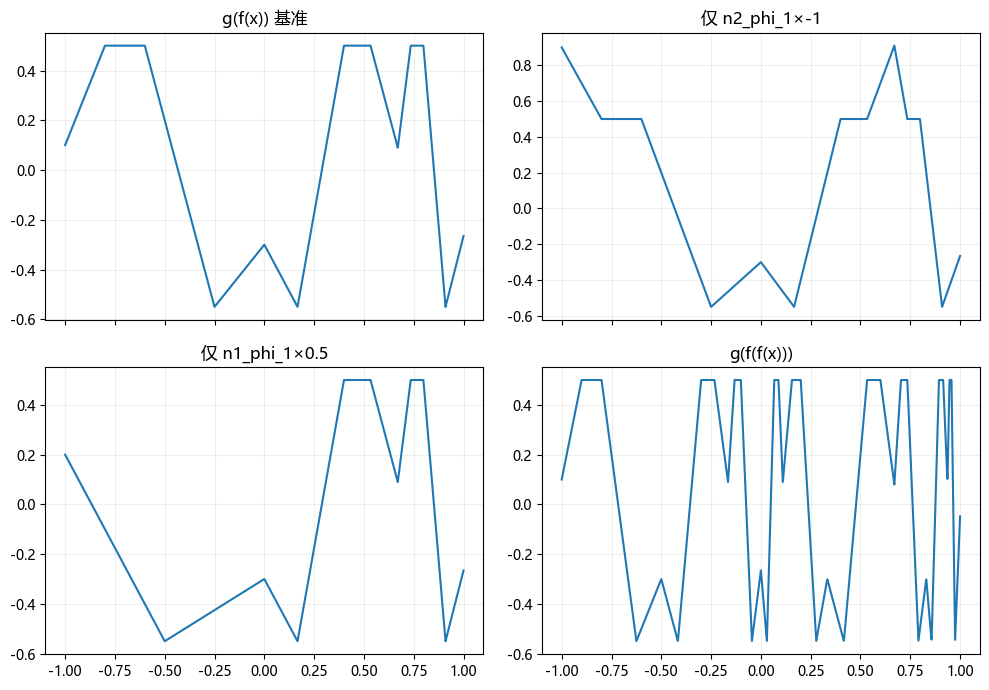

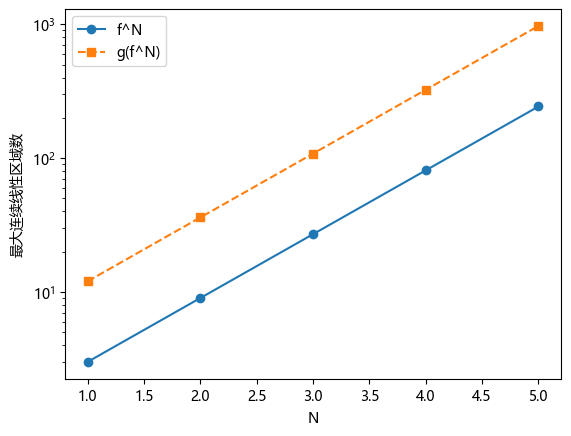

反例：若所有输出权重为0，任意深度输出恒定，最终始终只有1个线性区域。
解释：输入折叠表示多个输入区间映射到相同中间范围，后续网络复用函数片段且方向可翻转；它不会增加训练样本。


In [21]:
# 原参数与三个独立变参场景；每个场景都从原参数重新计算。
xv=np.unique(np.r_[np.arange(-1,1,0.001),[-1,1],
    [float(p["left"]) for p in base],[float(p["right"]) for p in base]])
base_y=g_np(f_np(xv))
flip_y=shallow_1_1_3(f_np(xv),ReLU,n2_phi_0,-n2_phi_1,n2_phi_2,n2_phi_3,n2_theta_10,n2_theta_11,n2_theta_20,n2_theta_21,n2_theta_30,n2_theta_31)
half_y=g_np(shallow_1_1_3(xv,ReLU,n1_phi_0,.5*n1_phi_1,n1_phi_2,n1_phi_3,n1_theta_10,n1_theta_11,n1_theta_20,n1_theta_21,n1_theta_30,n1_theta_31))
ff_y=f_np(f_np(xv)); gff_y=g_np(ff_y)
fig,ax=plt.subplots(2,2,figsize=(10,7),sharex=True)
for a,yv,title in zip(ax.ravel(),(base_y,flip_y,half_y,gff_y),("g(f(x)) 基准","仅 n2_phi_1×-1","仅 n1_phi_1×0.5","g(f(f(x)))")):
    a.plot(xv,yv); a.set_title(title); a.grid(alpha=.2)
fig.tight_layout(); plt.show()
fig,ax=plt.subplots();ax.plot(range(1,6),counts_f,'o-',label='f^N');ax.plot(range(1,6),counts_g,'s--',label='g(f^N)');ax.set_yscale('log');ax.set_xlabel('N');ax.set_ylabel('最大连续线性区域数');ax.legend();plt.show()
print("反例：若所有输出权重为0，任意深度输出恒定，最终始终只有1个线性区域。")
print("解释：输入折叠表示多个输入区间映射到相同中间范围，后续网络复用函数片段且方向可翻转；它不会增加训练样本。")